# OpenAlex from Python: green and circular-economy science in five blocks

**DAISY 2026 summer school, Taranto. Session "Publications as innovation data: measuring (green) science with OpenAlex, at scale with BigQuery"** (Massimiliano Coda Zabetta)

Leg B of the demo: the questions we ask VOSviewer (leg A) and BigQuery (leg C), asked to the OpenAlex REST API from Python with `pyalex` (J. de Bruin, github.com/J535D165/pyalex), `pandas` and `matplotlib`. This is the twin of `daisy_openalex_api_R.ipynb` (the one demoed in class): same blocks, same calls, same numbers.

Blocks: **B0** anatomy of a record and cost, **B1** trend, **B2** geography and RTA, **B3** SDG landscape, **B4** extras (not demoed).

Each block has: **concept** (what and why), **code** (one comment per line, with the Stata equivalent where one exists), **interpret** (what to say about the output), **exercise** (one line to try after the session).

Runtime: Colab, Python 3 (the default). Cells run top to bottom; nothing is loaded from disk. Written for pyalex 0.21 (February 2026) or later.

## Setup: packages and API key

Since 13 February 2026 the OpenAlex API expects a key for anything beyond light demo use. The key is free: log in at [openalex.org/settings/api](https://openalex.org/settings/api), copy it. A free key gives 1 USD of usage per day; a list, filter or group_by call costs 0.0001 USD, a text search 0.001 USD, a single-record lookup nothing. Keyless calls still work with a 0.10 USD daily budget (about 1,000 calls), enough to run this notebook once. Every response carries `meta.cost_usd`, so the price of a call is visible.

This notebook makes about 25 calls, roughly 0.003 USD with a key. Paste the key in the cell below; if you leave the placeholder, the calls run keyless.

`pyalex` 0.21 or later has `pyalex.config.api_key`; the first cell upgrades the package (Colab ships an older one or none).

In [ ]:
# Upgrade to the current pyalex (0.21 or later); a restart is not needed. The comment sits on its own line because on
# Windows a trailing "# ..." on a %pip line is passed to pip as arguments.
%pip install -U pyalex -q

In [1]:
import pyalex                                    # Python client for the OpenAlex API
from pyalex import Works, Institutions, Topics   # one class per entity
import pandas as pd                              # tables (Stata: the dataset in memory)
import matplotlib.pyplot as plt                  # charts
print(pyalex.__version__)                        # should print 0.21 or later
API_KEY = "PASTE-YOUR-KEY"                       # paste your key between the quotes (openalex.org/settings/api)
if API_KEY != "PASTE-YOUR-KEY":                  # a real key was pasted
    pyalex.config.api_key = API_KEY              # register once for the session; with the placeholder the calls run keyless
pyalex.config.email = "you@example.org"          # optional courtesy address (OpenAlex "polite pool")

0.21


## B0. Anatomy of one record

**Concept.** One OpenAlex work is a nested JSON record: flat fields (title, year, type, citations, FWCI), then lists inside it: authorships (each with author, position and one or more institutions with a country), topics (each with subfield, field, domain and a score; the first one is the `primary_topic`), keywords, SDG tags, referenced works. Our example is the review by Ghisellini, Cialani and Ulgiati (2016, *Journal of Cleaner Production*), OpenAlex id W1732240353, found with a free lookup by DOI (10.1016/j.jclepro.2015.09.007). `Works()["W..."]` returns the record as a Python dict; `pd.DataFrame()` turns any list of dicts into a table (Stata: `reshape long`).

In [3]:
# Fetch one work by its OpenAlex id (single lookups are free; a DOI works too: Works()["https://doi.org/10.1016/j.jclepro.2015.09.007"])
paper = Works()["W1732240353"]
# Flat fields: a dict, one key per field (Stata: list title year type citations in 1)
{k: paper[k] for k in ["display_name", "publication_year", "type", "cited_by_count", "fwci"]}

{'display_name': 'A review on circular economy: the expected transition to a balanced interplay of environmental and economic systems',
 'publication_year': 2015,
 'type': 'article',
 'cited_by_count': 6308,
 'fwci': 335.8188}

In [4]:
# The primary topic and its hierarchy: topic, subfield, field, domain
(paper["primary_topic"]["display_name"], paper["primary_topic"]["subfield"]["display_name"],
 paper["primary_topic"]["field"]["display_name"], paper["primary_topic"]["domain"]["display_name"])

('Sustainable Supply Chain Management',
 'Strategy and Management',
 'Business, Management and Accounting',
 'Social Sciences')

In [5]:
# All topics of the paper as a table (a list of dicts becomes rows); the first row is the primary topic
pd.DataFrame(paper["topics"])[["id", "display_name", "score"]]

,id,display_name,score
0,https://openalex.org/T10539,Sustainable Supply Chain Management,0.9995
1,https://openalex.org/T12746,Sustainable Industrial Ecology,0.9991
2,https://openalex.org/T13180,Chemistry and Chemical Engineering,0.9897


In [6]:
# SDG tags: an empty list here, the classifier gave this circular-economy review no SDG (keep this in mind for B3)
paper["sustainable_development_goals"]

[]

In [7]:
# Authorships: one row per author and institution (Stata: reshape long twice, authors then institutions)
rows = [{"author": a["author"]["display_name"], "position": a["author_position"],
         "institution": i["display_name"], "country": i["country_code"]}
        for a in paper["authorships"] for i in a["institutions"]]   # nested loop: authors, then their institutions
pd.DataFrame(rows)   # one row per author x institution

,author,position,institution,country
0,Patrizia Ghisellini,first,University of Bologna,IT
1,Catia Cialani,middle,Dalarna University,SE
2,Sérgio Ulgiati,last,Parthenope University of Naples,IT
3,Sérgio Ulgiati,last,Beijing Normal University,CN


In [8]:
# The price of a call: ask for one record and read the meta block (count of matches and cost_usd)
res = Works().filter(primary_topic={"id": "T10471"}).get(per_page=1)   # T10471 = Climate Change Policy and Economics
res.meta["count"], res.meta["cost_usd"]                                # about 105,000 works in Aug 2026; 0.0001 USD for a filter call

(104773, 0.0001)

**Interpret.** Year 2015, not 2016: OpenAlex records the earliest publication date (online first). Three authors, four author-institution rows, two countries for one author: counting by country requires a decision (whole or fractional). The primary topic is T10539 "Sustainable Supply Chain Management" (subfield Strategy and Management), the closest OpenAlex topic to "circular economy"; no topic is named circular economy, which is why B1 and B2 use a set of topics. The SDG list is empty: a classifier assigns SDG tags, and it misses this paper (SDG 12 would be the natural tag).

**Exercise.** Replace the identifier with the DOI of your own paper (or Kirchherr, Reike and Hekkert 2017, W2756283300) and check its topics and SDGs.

## B1. Trend: is climate and circular-economy science growing faster than science?

**Concept.** `group_by` asks the server to count works by a field and to send back only the small table of counts (Stata: `collapse (count), by(year)`, done on OpenAlex's side). One call gives the numerator (works in a topic, by year), one call the denominator (all works, by year); the share tells whether the field grows faster than the total. Topic T10471 is "Climate Change Policy and Economics" (about 105,000 works, 69,000 of them in 2010-2025). For circular economy we pass a set of topic ids as an OR list. In pyalex a filter is a keyword argument, nested fields are dicts (`primary_topic={"id": "T10471"}`), and several values joined with `|` form an OR list.

In [2]:
# Works whose primary topic is T10471, counted by publication year on the server (Stata: collapse (count) id, by(year))
cc_year = pd.DataFrame(Works().filter(primary_topic={"id": "T10471"}, publication_year="2010-2025").group_by("publication_year").get())
# All works by year, no topic filter: the denominator
all_year = pd.DataFrame(Works().filter(publication_year="2010-2025").group_by("publication_year").get())
cc_year.head(3)   # columns: key (the year, as text), key_display_name, count

,key,key_display_name,count
0,2024,2024,4994
1,2023,2023,4864
2,2025,2025,4809


In [3]:
# Circular-economy topic set: the 28 topics of session/data/ce_topic_ids_api.txt (names, work counts and pruning notes in session/data/README.md);
# the same list is inlined in the SQL of leg C and pasted in the VOSviewer URL of leg A, so the three legs answer on the same set.
# The set is a choice (T10539 Sustainable Supply Chain Management, T12017 Recycling and Waste Management Techniques, T11091 Extraction and Separation
# Processes for battery recycling, T13180 green chemistry, ...); prune it here and every number in B1 and B2 changes.
ce_topics = [
             "T10171", "T10264", "T10284", "T10435",
             "T10539", "T10753", "T11091", "T11108",
             "T11275", "T11672", "T11781", "T11847",
             "T12017", "T12118", "T12186", "T12746",
             "T12774", "T12838", "T12920", "T13045",
             "T13140", "T13180", "T13240", "T13477",
             "T13790", "T14138", "T14164", "T14179"]
ce_or = "|".join(ce_topics)   # the OR list the API expects: T10171|T10264|... (up to 100 values per filter)
len(ce_topics)                # 28
# CE works by year: the same group_by call with the OR list as the topic filter
ce_year = pd.DataFrame(Works().filter(primary_topic={"id": ce_or}, publication_year="2010-2025").group_by("publication_year").get())

In [4]:
# Merge the three tables on year (Stata: merge 1:1 year) and compute shares of world output
trend = (all_year[["key", "count"]].rename(columns={"key": "year", "count": "all"})                       # denominator
         .merge(cc_year[["key", "count"]].rename(columns={"key": "year", "count": "climate"}), on="year")   # add T10471 counts
         .merge(ce_year[["key", "count"]].rename(columns={"key": "year", "count": "circular"}), on="year"))  # add CE counts
trend["year"] = trend["year"].astype(int)                         # key comes back as text
trend["climate_share"] = 100 * trend["climate"] / trend["all"]     # share of world output, in percent
trend["circular_share"] = 100 * trend["circular"] / trend["all"]   # same for the CE set
trend = trend.sort_values("year").reset_index(drop=True)          # chronological order
trend                                                             # print the table (Stata: list)

,year,all,climate,circular,climate_share,circular_share
0,2010,8112217,4285,36704,0.052822,0.452453
1,2011,8689341,4466,40829,0.051396,0.469875
2,2012,8989308,4261,43650,0.047401,0.485577
3,2013,9437917,4392,46374,0.046536,0.491358
4,2014,9988296,4207,49725,0.042119,0.497833
5,2015,10204783,4438,51476,0.043489,0.504430
6,2016,10603268,4299,50844,0.040544,0.479513
7,2017,10471902,3901,51425,0.037252,0.491076
8,2018,10410009,3918,55521,0.037637,0.533342
9,2019,10782293,3955,59343,0.036681,0.550375


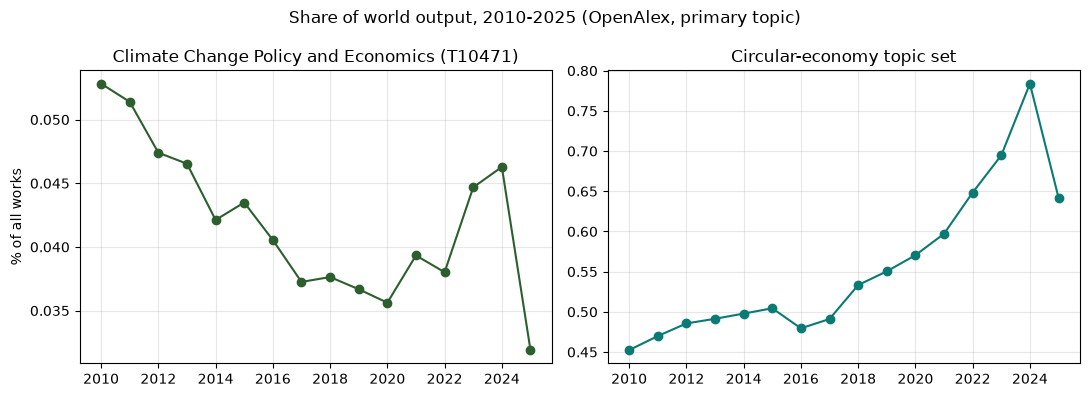

In [5]:
# Two panels: the two shares differ by an order of magnitude
fig, axes = plt.subplots(1, 2, figsize=(11, 4))                                     # one figure, two axes side by side
axes[0].plot(trend["year"], trend["climate_share"], marker="o", color="#2C5F2D")   # left: T10471 share
axes[0].set_title("Climate Change Policy and Economics (T10471)")                 # left title
axes[1].plot(trend["year"], trend["circular_share"], marker="o", color="#0B7A75")  # right: CE share
axes[1].set_title("Circular-economy topic set")                                    # right title
axes[0].set_ylabel("% of all works"); axes[0].grid(alpha=0.3); axes[1].grid(alpha=0.3)   # y label and light grids
fig.suptitle("Share of world output, 2010-2025 (OpenAlex, primary topic)")        # overall title
plt.tight_layout(); plt.show()                                                     # draw

**Interpret.** The circular-economy share rises steadily, from 0.45 percent of world output in 2010 to 0.78 percent in 2024 (numbers of 18 Aug 2026): the set grows faster than science as a whole. The climate-economics share (T10471) does not: it slips from 0.053 to 0.036 percent by 2020 and recovers to 0.046 in 2024, a reminder that one topic is a narrow net (climate economics also lives in energy, environmental science and policy topics). In 2025 the denominator jumps (15.1 million works against 10.8 million in 2024), which pulls both shares down: an ingestion artefact of the new data model rather than a change in science. TODO instructor: rerun at rehearsal; if the jump persists, end the chart in 2024 or restrict to `type = "article"`. Read the level with care: a work has one primary topic, so a paper on the economics of recycling filed under an economics topic is not in the numerator, and the denominator counts everything OpenAlex indexes in its core corpus (`corpus=core` is the API default: the 190 million low-metadata "xpac" records are excluded from numerator and denominator alike).

**Exercise.** Restrict numerator and denominator to `type = "article"` and see whether the shares change.

## B2. Geography: who specialises in circular-economy science?

**Concept.** `group_by = "authorships.countries"` counts, for each country, the works with at least one author affiliated there (whole counting: a paper with Italian and German authors counts once for each country). Dividing a country's share of circular-economy works by its share of all works gives the revealed technological advantage index (RTA, the Balassa index of the patent literature): above 1, the country publishes more on the topic than its size predicts. The same logic runs at institution level; OpenAlex institutions carry a `geo` block with the region, so Italian institutions aggregate to Italian regions.

In [6]:
# Circular-economy works 2020-2025 by country of the authors' institutions (whole counting), and all works by country
ce_country  = pd.DataFrame(Works().filter(primary_topic={"id": ce_or}, publication_year="2020-2025").group_by("authorships.countries").get())   # numerator
all_country = pd.DataFrame(Works().filter(publication_year="2020-2025").group_by("authorships.countries").get())                            # denominator
# key is a URL like https://openalex.org/countries/IT: keep the last part as the country code (Stata: substr or regexs)
ce_country["country"]  = ce_country["key"].str.split("/").str[-1]    # ISO-2 code from the URL
all_country["country"] = all_country["key"].str.split("/").str[-1]   # same for the denominator
rta_country = (ce_country[["country", "key_display_name", "count"]].rename(columns={"key_display_name": "country_name", "count": "ce"})   # code, name, CE count
               .merge(all_country[["country", "count"]].rename(columns={"count": "all"}), on="country"))   # Stata: merge 1:1 country
rta_country["rta"] = (rta_country["ce"] / rta_country["ce"].sum()) / (rta_country["all"] / rta_country["all"].sum())   # share in CE over share in all
rta_country = rta_country.sort_values("ce", ascending=False).reset_index(drop=True)   # largest CE producers first
rta_country.head(10)                                                                   # top 10 by CE count

,country,country_name,ce,all,rta
0,CN,China,78298,6633709,1.362076
1,US,United States,33220,8306561,0.461514
2,IN,India,29040,2431745,1.378115
3,ID,Indonesia,25805,2373619,1.254584
4,BR,Brazil,16055,1435085,1.291040
5,GB,United Kingdom,14489,2252582,0.742275
6,DE,Germany,12507,1896407,0.761077
7,IT,Italy,11521,1347255,0.986841
8,RU,Russia,10435,1088102,1.106700
9,FR,France,10388,1637351,0.732145


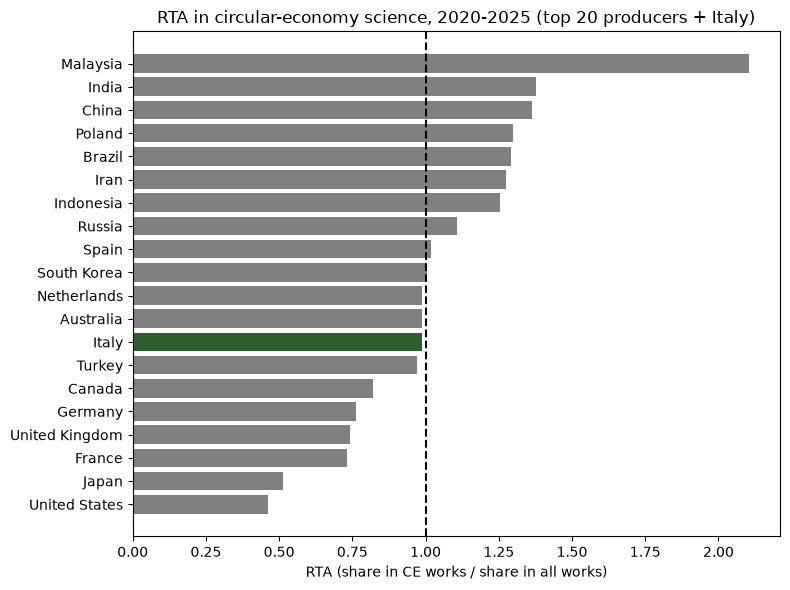

In [7]:
# Top 20 producers plus Italy, bar chart of RTA (Italy in a different colour)
top20 = rta_country.head(20)                       # the 20 largest CE producers
if "IT" not in top20["country"].values:            # Italy outside the top 20?
    top20 = pd.concat([top20, rta_country[rta_country["country"] == "IT"]])   # add Italy if it is not in the top 20
top20 = top20.sort_values("rta")                   # bars sorted by RTA
colors = ["#2C5F2D" if c == "IT" else "grey" for c in top20["country"]]   # green for Italy, grey for the others
plt.figure(figsize=(8, 6))                         # new figure
plt.barh(top20["country_name"], top20["rta"], color=colors)   # horizontal bars
plt.axvline(1, linestyle="--", color="black")      # RTA = 1: no specialisation
plt.title("RTA in circular-economy science, 2020-2025 (top 20 producers + Italy)")   # title
plt.xlabel("RTA (share in CE works / share in all works)")   # x label
plt.tight_layout(); plt.show()                     # draw

### Italian regions

Two calls give the counts by institution (works with at least one Italian institution, grouped by institution id) and one call gives the location of the 200 largest Italian institutions. `pyalex` returns the first page of a `group_by`, which is the 200 largest groups: exactly what we want here (foreign co-author institutions appear too and are dropped by the merge). A data-quality patch follows: in the June 2026 data most institutions have a city but no region in `geo`, so a small city-to-region table fills the gap.

In [8]:
# Works with at least one Italian institution, grouped by institution id: the 200 largest groups (foreign co-author institutions included)
ce_inst  = pd.DataFrame(Works().filter(authorships={"institutions": {"country_code": "IT"}}, primary_topic={"id": ce_or}, publication_year="2020-2025").group_by("authorships.institutions.id").get())   # CE works, by institution
all_inst = pd.DataFrame(Works().filter(authorships={"institutions": {"country_code": "IT"}}, publication_year="2020-2025").group_by("authorships.institutions.id").get())                            # all works, by institution
all_inst.head(5)   # some counts look inflated: institution disambiguation noise in the June 2026 data

,key,key_display_name,count
0,https://openalex.org/I189158943,University of Milan,197826
1,https://openalex.org/I93860229,Politecnico di Milano,173916
2,https://openalex.org/I4210136779,"Istituto Nazionale di Fisica Nucleare, Sezione...",132987
3,https://openalex.org/I1299204452,Oeschger Centre for Climate Change Research,129921
4,https://openalex.org/I861853513,Sapienza University of Rome,81098


In [9]:
# Region of the 200 largest Italian institutions in one call (sorted by works_count); the geo block has city, region, country
inst_it = Institutions().filter(country_code="IT").sort(works_count="desc").select(["id", "display_name", "geo"]).get(per_page=200)   # one page of 200
inst_geo = pd.DataFrame([{"key": i["id"], "institution": i["display_name"], "city": (i["geo"] or {}).get("city"),   # one row per institution
                          "region": (i["geo"] or {}).get("region")} for i in inst_it])   # Stata: keep id name city region
print(inst_geo["region"].isna().sum(), "of 200 without a region")   # data quality: on 18 Aug 2026 about 130 have no region in geo, but all have a city
inst_geo.head(5)   # first five institutions

130 of 200 without a region


,key,institution,city,region
0,https://openalex.org/I189158943,University of Milan,Milan,NaN
1,https://openalex.org/I93860229,Politecnico di Milano,Milan,Lombardy
2,https://openalex.org/I861853513,Sapienza University of Rome,Rome,Lazio
3,https://openalex.org/I9360294,University of Bologna,Bologna,Emilia-Romagna
4,https://openalex.org/I138689650,University of Padua,Padua,Veneto


In [10]:
# Patch: a city-to-region lookup for the cities of these 200 institutions (region names as OpenAlex spells them)
city_region = {
  "Ancona": "The Marches", "Aviano": "Friuli Venezia Giulia", "Bari": "Apulia", "Benevento": "Campania",
  "Bergamo": "Lombardy", "Bologna": "Emilia-Romagna", "Bolzano": "Trentino-Alto Adige", "Brescia": "Lombardy",
  "Cagliari": "Sardinia", "Camerino": "The Marches", "Campobasso": "Molise", "Candiolo": "Piedmont",
  "Caserta": "Campania", "Cassino": "Lazio", "Catania": "Sicily", "Catanzaro": "Calabria",
  "Chieti": "Abruzzo", "Enna": "Sicily", "Ferrara": "Emilia-Romagna", "Fisciano": "Campania",
  "Florence": "Tuscany", "Foggia": "Apulia", "Frascati": "Lazio", "Genoa": "Liguria",
  "Ispra": "Lombardy", "Lavagna": "Liguria", "Lecce": "Apulia", "Legnaro": "Veneto",
  "L’Aquila": "Abruzzo", "L'Aquila": "Abruzzo", "Macerata": "The Marches", "Meldola": "Emilia-Romagna",
  "Messina": "Sicily", "Milan": "Lombardy", "Modena": "Emilia-Romagna", "Monserrato": "Sardinia",
  "Monza": "Lombardy", "Naples": "Campania", "Padua": "Veneto", "Palermo": "Sicily",
  "Parma": "Emilia-Romagna", "Pavia": "Lombardy", "Perugia": "Umbria", "Pino Torinese": "Piedmont",
  "Pisa": "Tuscany", "Potenza": "Basilicata", "Pozzilli": "Molise", "Reggio Calabria": "Calabria",
  "Reggio Emilia": "Emilia-Romagna", "Rende": "Calabria", "Rome": "Lazio", "Rozzano": "Lombardy",
  "San Donato Milanese": "Lombardy", "San Giovanni Rotondo": "Apulia", "San Michele all'Adige": "Trentino-Alto Adige", "Sassari": "Sardinia",
  "Sesto Fiorentino": "Tuscany", "Siena": "Tuscany", "Teramo": "Abruzzo", "Trento": "Trentino-Alto Adige",
  "Trieste": "Friuli Venezia Giulia", "Turin": "Piedmont", "Udine": "Friuli Venezia Giulia", "Urbino": "The Marches",
  "Varese": "Lombardy", "Venice": "Veneto", "Vercelli": "Piedmont", "Verona": "Veneto",
  "Viterbo": "Lazio"}
# Keep the region when present, else look it up from the city (Stata: replace region = lookup if missing(region))
inst_geo["region"] = inst_geo["region"].fillna(inst_geo["city"].map(city_region))
inst_geo["region"].isna().sum()   # institutions still without a region (city not in the lookup) are dropped by the merges below

np.int64(0)

In [11]:
# Merge counts with regions (inner merge drops foreign and small institutions) and sum by region (Stata: merge m:1, collapse (sum) count, by(region))
ce_region  = ce_inst.merge(inst_geo, on="key").groupby("region")["count"].sum().rename("ce")     # CE count per region
all_region = all_inst.merge(inst_geo, on="key").groupby("region")["count"].sum().rename("all")   # total count per region
rta_region = pd.concat([all_region, ce_region], axis=1).fillna(0)          # regions with no CE institution get 0
rta_region["rta"] = (rta_region["ce"] / rta_region["ce"].sum()) / (rta_region["all"] / rta_region["all"].sum())   # Italy = 1
rta_region = rta_region.sort_values("rta", ascending=False)               # most specialised region first
rta_region                                                                # print the table

,all,ce,rta
region,,,
Basilicata,5284,91,2.538146
The Marches,28806,485,2.481400
Calabria,27017,364,1.985648
Sicily,69420,928,1.970160
Campania,120820,1575,1.921232
Molise,5353,63,1.734528
Apulia,54231,604,1.641449
Piedmont,90309,847,1.382262
Umbria,19765,184,1.372016


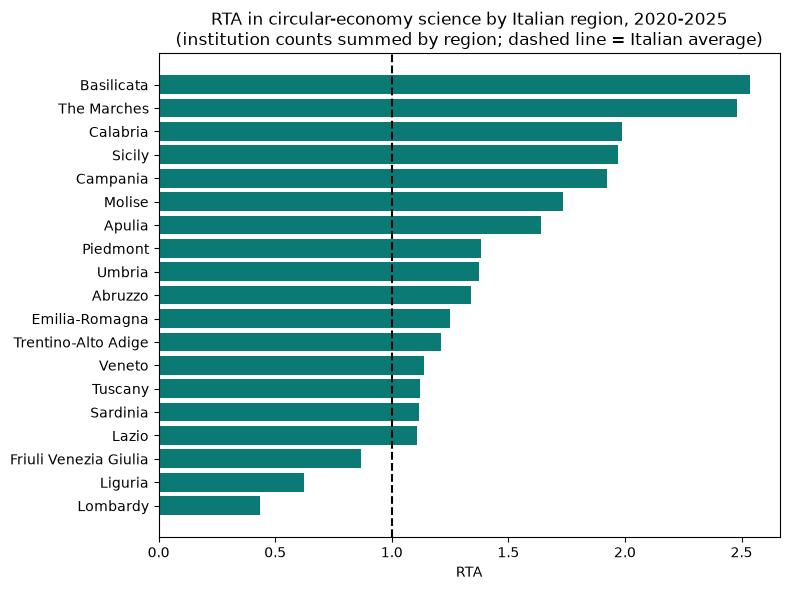

In [12]:
# Bar chart of the regional RTA, regions sorted by RTA
plt.figure(figsize=(8, 6))                                                  # new figure
plt.barh(rta_region.index[::-1], rta_region["rta"][::-1], color="#0B7A75")  # horizontal teal bars, largest on top
plt.axvline(1, linestyle="--", color="black")                               # RTA = 1: the Italian average
plt.title("RTA in circular-economy science by Italian region, 2020-2025\n(institution counts summed by region; dashed line = Italian average)")   # title
plt.xlabel("RTA"); plt.tight_layout(); plt.show()                           # x label, draw

**Interpret.** China leads the raw counts (78,000 works in 2020-2025 on 18 Aug 2026), then the United States, India, Indonesia and Brazil. The RTA tells a different story: India (1.38), China (1.36), Brazil (1.29) and Indonesia (1.25) are specialised, the United States (0.46), France (0.73), the United Kingdom (0.74) and Germany (0.76) are not; Italy sits at the world average (0.99), the highest of the large western European producers. Waste-management and recycling topics have a large output in emerging economies (local journals, applied engineering), so the topic set decides the answer: state it and keep the id list next to the results. Regional RTAs rest on institution counts: they double count multi-institution papers, they inherit OpenAlex's institution disambiguation errors (a few Italian institutions show implausible totals in the June 2026 data), and they needed a patch because two thirds of the largest Italian institutions have no `region` in their `geo` block, only a city. With that patch, southern and central regions lead (Basilicata, the Marches, Calabria, Sicily, Campania, Molise and Apulia, the region hosting the school, all above 1.6) and Friuli Venezia Giulia, Liguria and Lombardy (0.44) close the ranking; the Aosta Valley has no institution in the top 200 and does not appear. TODO instructor: reread the regional table at rehearsal, the numbers move with each OpenAlex update. Compare with the BigQuery answer in leg C, which counts every work without the 200-group cap.

**Exercise.** Swap the topic set for `"T10471"` and redo the country RTA for climate economics.

## B3. SDG landscape: what is Italy's SDG research made of?

**Concept.** OpenAlex tags works with UN Sustainable Development Goals (`sustainable_development_goals`, id `https://openalex.org/sdgs/13` for climate action) with a classifier trained on the Aurora SDG queries. `group_by = "sustainable_development_goals.id"` for one country gives its SDG profile in one call (the OpenAlex recipe "Map SDG research", help.openalex.org/tutorials/map-sdg-research/); two countries side by side show different priorities; filtering on one SDG and grouping by subfield shows what a goal is made of. Caveat: SDG tags are classifier output, and databases and classifiers disagree on which papers count (Kashnitsky et al. 2024, *Quantitative Science Studies* 5(2) 408-425, doi:10.1162/qss_a_00304; Ottaviani and Stahlschmidt 2024, arXiv:2405.03007).

In [19]:
# SDG counts for Italy and Germany, 2020-2025 (Stata: two collapse (count), by(sdg), then append)
sdg_it = pd.DataFrame(Works().filter(authorships={"countries": "IT"}, publication_year="2020-2025").group_by("sustainable_development_goals.id").get())
sdg_de = pd.DataFrame(Works().filter(authorships={"countries": "DE"}, publication_year="2020-2025").group_by("sustainable_development_goals.id").get())   # TODO instructor: pick the partner country
sdg_it["country"] = "IT"; sdg_de["country"] = "DE"                   # label each table with its country
sdg = pd.concat([sdg_it, sdg_de])                                    # Stata: append
sdg["sdg_n"] = sdg["key"].str.split("/").str[-1].astype(int)         # SDG number from the URL https://openalex.org/sdgs/13
totals = all_country.set_index("country")["count"]                   # each country's total works 2020-2025, from B2
sdg["share_pct"] = 100 * sdg["count"] / sdg["country"].map(totals)   # share of the country's works carrying the tag
sdg.sort_values(["country", "share_pct"], ascending=[True, False])[["country", "sdg_n", "key_display_name", "count", "share_pct"]].head(10)   # top SDGs per country

,country,sdg_n,key_display_name,count,share_pct
0,DE,3,Good health and well-being,224222,11.823517
1,DE,7,Affordable and clean energy,98685,5.203788
2,DE,10,Reduced inequalities,70050,3.693827
3,DE,2,Zero hunger,61837,3.260745
4,DE,14,Life below water,57255,3.019130
5,DE,4,Quality education,55484,2.925743
6,DE,16,"Peace, justice, and strong institutions",53099,2.799979
7,DE,15,Life on land,50335,2.654230
8,DE,9,"Industry, innovation and infrastructure",45764,2.413195
9,DE,13,Climate action,42916,2.263016


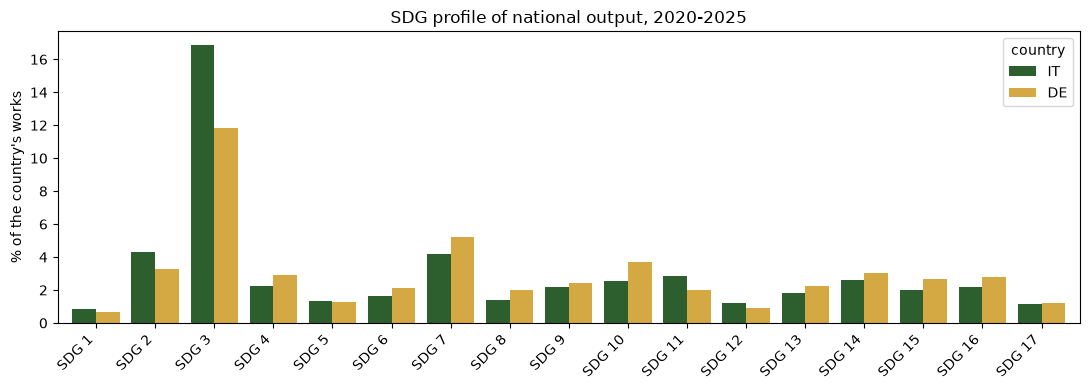

In [20]:
# Paired bar chart: SDGs in numeric order, one bar per country (Stata: reshape wide then graph bar)
wide = sdg.pivot(index="sdg_n", columns="country", values="share_pct").sort_index()[["IT", "DE"]]   # one row per SDG, one column per country
ax = wide.plot.bar(figsize=(11, 4), color=["#2C5F2D", "#D4A843"], width=0.8)                        # side-by-side bars, green Italy, gold Germany
ax.set_xticklabels(["SDG " + str(n) for n in wide.index], rotation=45, ha="right")                  # "SDG 1" ... "SDG 17", tilted
ax.set_xlabel(None); ax.set_ylabel("% of the country's works"); ax.set_title("SDG profile of national output, 2020-2025")   # labels
plt.tight_layout(); plt.show()                                                                       # draw

In [21]:
# What is Italy's SDG 13 (climate action) research made of? Filter on the SDG and group by subfield of the primary topic
sdg13_sub = pd.DataFrame(Works().filter(authorships={"countries": "IT"}, sustainable_development_goals={"id": "https://openalex.org/sdgs/13"},
                                        publication_year="2020-2025").group_by("primary_topic.subfield.id").get())
sdg13_sub["share_pct"] = 100 * sdg13_sub["count"] / sdg13_sub["count"].sum()   # share within the 200 largest subfields returned (of 236)
sdg13_sub[["key_display_name", "count", "share_pct"]].head(10)                  # Stata: gsort -count, list in 1/10

,key_display_name,count,share_pct
0,Global and Planetary Change,2903,11.970147
1,Atmospheric Science,1674,6.902524
2,"Management, Monitoring, Policy and Law",1014,4.181098
3,Sociology and Political Science,863,3.558469
4,Economics and Econometrics,824,3.397658
5,Geophysics,812,3.348177
6,Astronomy and Astrophysics,771,3.179119
7,Civil and Structural Engineering,714,2.944087
8,Artificial Intelligence,698,2.878113
9,Environmental Engineering,633,2.610094


**Interpret.** SDG 3 (health) dominates every country's profile because biomedical output is large (about 12 percent of German and 17 percent of Italian works carry the tag); the reading is relative: where Italy's bar exceeds Germany's and where it falls short (TODO instructor: name the two or three goals from the chart at rehearsal). Italy's SDG 13 output is led by Global and Planetary Change (12 percent) and Atmospheric Science (7 percent); the policy and social science subfields (Management, Monitoring, Policy and Law; Sociology and Political Science; Economics and Econometrics) follow with 3 to 4 percent each, ahead of most engineering subfields. Confraria, Ciarli and Noyons (2024, *Research Policy* 53(3) 104950) read such profiles as research priorities; here they are also a property of the classifier: repeat the profile with the Scopus or Web of Science SDG filters and the ranking changes, so the caveat above is not a footnote.

**Exercise.** Replace SDG 13 with SDG 12 (responsible consumption and production) and compare the subfield mix with the circular-economy topic set of B1.

## B4. Extras (not demoed): counting, snowballing, sampling, exporting

**Concept.** Four things you will need in your own work: count before you download; build a citation neighbourhood around a paper (the works it cites and the works citing it, with a filter on the citing side to keep the volume down); draw a random sample of a large set instead of downloading it all (reproducible thanks to a seed); write the result to CSV or Stata. In pyalex: `.count()`, the `cited_by` and `cites` filters, `.sample(200, seed=42)`, and pandas `to_csv()` / `to_stata()`.

In [13]:
# Count before you download: how many circular-economy articles 2020-2025? (Stata: count if ...)
Works().filter(primary_topic={"id": ce_or}, publication_year="2020-2025", type="article").count()

295333

In [23]:
# Citation neighbourhood of one paper: the works it cites (filter cited_by) and the works citing it since June 2026 (filter cites, restricted to keep the download small)
cited  = Works().filter(cited_by="W1732240353").select(["id", "display_name", "publication_year"]).get(per_page=200)                                   # works in its reference list
citing = Works().filter(cites="W1732240353", from_publication_date="2026-06-01").select(["id", "display_name", "publication_year"]).get(per_page=200)   # works citing it since June 2026
len(cited), cited.meta["count"], len(citing), citing.meta["count"]   # 172 of the 189 references resolve to OpenAlex works; citing works: first page of 200 and total (paginate() for all pages)

(172, 172, 139, 139)

In [14]:
# Random sample of 200 circular-economy articles 2020-2025 (Stata: set seed 42, sample 200, count); the seed makes it reproducible
ce_sample = pd.DataFrame(Works().filter(primary_topic={"id": ce_or}, publication_year="2020-2025", type="article")
                         .sample(200, seed=42).select(["id", "display_name", "publication_year", "cited_by_count"]).get(per_page=200))
ce_sample["cited_by_count"].describe()          # skewed as always: median small, mean pulled up by a few papers

count    200.000000
mean      21.870000
std       55.306665
min        0.000000
25%        0.000000
50%        6.000000
75%       23.000000
max      628.000000
Name: cited_by_count, dtype: float64

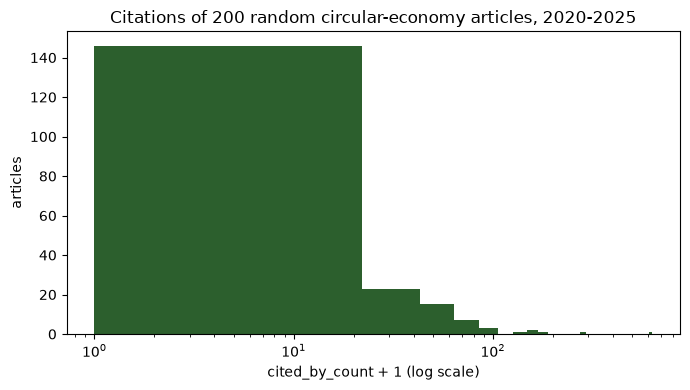

In [15]:
# Histogram of the citations of the 200 sampled articles, on a log axis
plt.figure(figsize=(7, 4))                                             # new figure
plt.hist(ce_sample["cited_by_count"] + 1, bins=30, color="#2C5F2D")   # +1 so that zero-citation papers survive the log scale
plt.xscale("log"); plt.xlabel("cited_by_count + 1 (log scale)"); plt.ylabel("articles")   # log x axis, labels
plt.title("Citations of 200 random circular-economy articles, 2020-2025"); plt.tight_layout(); plt.show()   # title, draw

In [16]:
# Export to CSV and Stata (Stata: export delimited, save); in Colab, download from the Files pane on the left
rta_country.to_csv("rta_country_2020_2025.csv", index=False)           # CSV in the working directory
rta_country.to_stata("rta_country_2020_2025.dta", write_index=False)   # column names must be valid Stata names (they are)
# In Colab you can also push the file to your browser: from google.colab import files; files.download("rta_country_2020_2025.dta")
import os                                                              # to list the working directory
[f for f in os.listdir() if f.startswith("rta_country")]               # the two files just written

['rta_country_2020_2025.csv', 'rta_country_2020_2025.dta']

**Interpret.** Counting first is the habit that keeps a project inside its budget: a count costs 0.0001 USD, a download of 100,000 works costs 500 calls of 200 records and minutes of waiting. Snowballing is how a literature review or a knowledge-flow measure starts; sampling is how you look at a population you cannot download in a session; the export is what enters your Stata do-file.

**Exercise.** Snowball around your own most-cited paper and count how many citing works carry an SDG tag.

## Where the same numbers come from elsewhere

Leg C (BigQuery, `subugoe-collaborative.openalex_walden.works`, June 2026 snapshot) recomputes B1 and B2 with SQL over every record: no 200-group cap, no paging, and the `is_xpac` flag replaces the API's `corpus=core` default. Expect small differences from snapshot dates and from the group cap. See `notebook/README.md` for the mapping between the R and Python versions.

## Build notes (for the instructor)

Outputs stored in this notebook were produced on 18 Aug 2026 with pyalex 0.21, keyless, from a local Python 3.12 (see `_build/execute_python_nb.py` and `_build/splice_outputs.py`: B0 and B3 from the first full run, the topic-set-dependent cells re-run the same day with the final 28-topic list). Numbers move as OpenAlex updates; the ones to compare with leg C are the B1 shares and the B2 country counts. `pyalex` returns the first page of a `group_by` (the 200 largest groups) unless you paginate; the R twin behaves differently (openalexR pages through all groups), which is why the R notebook builds the institution URL by hand.